### Importing the libraries

In [1]:
# Core/utility libraries
import os
import glob
from pathlib import Path
import random
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Image IO & processing
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Deep learning frameworks - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader , Subset
from torchvision import transforms, datasets
import torchvision.transforms.functional as F
from torch.cuda.amp import autocast, GradScaler

# Data splitting and utilities
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight



# 1.1 Loading imagees

## 1.1.1 Giving path of the file

In [2]:
train_dir = r"D:\D drive\Project\AI That Explains Medical Images Like a Doctor\Images Dataset\Train"
test_dir = r"D:\D drive\Project\AI That Explains Medical Images Like a Doctor\Images Dataset\test"
csv_path = r"D:\D drive\Project\AI That Explains Medical Images Like a Doctor\Dataset\stage_2_detailed_class_info.csv"
# csv_path2 = r"D:\Project\AI That Explains Medical Images Like a Doctor\Another way\Dataset\stage_2_detailed_class_info.csv"

## 1.1.2 Loading the images of the train directorires

In [3]:
# # No resize here
# transform = transforms.Compose([
#     transforms.ToTensor()
# ])

In [4]:
transform = transforms.Compose([
    transforms.Resize(256),       # downscale big image
    transforms.CenterCrop(224),   # zoomed center
    transforms.ToTensor(),
])


In [5]:
class XrayDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.df.columns = self.df.columns.str.strip()
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        class_folder = row["class"]

        image_path = os.path.join(
            self.image_dir,
            class_folder,
            row["patientId"] + ".png"
        )

        if not os.path.exists(image_path):
            raise FileNotFoundError(image_path)

        # 🔹 Load PIL image
        image = Image.open(image_path).convert("RGB")

        # 🔹 Original size (PIL)
        orig_w, orig_h = image.size

        # 🔹 Resize image (PIL)
        image = image.resize((256, 256))

        # 🔹 Bounding box values
        x = row["x"]
        y = row["y"]
        w = row["width"]
        h = row["height"]

        if pd.isna(x):
            has_object = 0
            bbox = torch.zeros(4, dtype=torch.float32)
        else:
            has_object = 1

            # 🔹 Scale bbox to resized image
            x = x * 256 / orig_w
            y = y * 256 / orig_h
            w = w * 256 / orig_w
            h = h * 256 / orig_h

            x /= 256
            y /= 256
            w /= 256
            h /= 256
            
            bbox = torch.tensor([x, y, w, h], dtype=torch.float32)

        # 🔹 Transform LAST (PIL → Tensor)
        if self.transform:
            image = self.transform(image)

        return image, bbox, torch.tensor(has_object, dtype=torch.float32)


In [6]:
train_dataset = XrayDataset(
    csv_file=csv_path,
    image_dir=train_dir,
    transform=transform
)


In [7]:
# batch_size = 1 (IMPORTANT)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,      # or 2 if system is weak
    # pin_memory=True     # 🔥 VERY IMPORTANT
)


In [8]:
print("Total samples:", len(train_dataset))
print(train_dataset.df.columns)
print(train_dataset.df[["x", "y", "width", "height"]].head())
train_dataset.classes = ["NO lung opacity", "Normal", "Lung Opacity"]


Total samples: 30227
Index(['patientId', 'x', 'y', 'width', 'height', 'Target', 'class'], dtype='object')
       x      y  width  height
0    NaN    NaN    NaN     NaN
1    NaN    NaN    NaN     NaN
2    NaN    NaN    NaN     NaN
3    NaN    NaN    NaN     NaN
4  264.0  152.0  213.0   379.0


## 1.1.3 Loading all test images

In [9]:

class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = os.listdir(image_dir)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.image_files[idx]  # return filename for tracking

In [10]:
test_dataset = TestDataset(
    image_dir=test_dir,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False   # IMPORTANT: keep order
)


# 2 Model creation

In [11]:
device = torch.device("cuda")
print("Using device:", device)


Using device: cuda


## 2.2 Custom model creation using the csv file

### 2.2.1 Bounding box scaling

In [12]:
def scale_bbox(x, y, w, h, orig_w, orig_h, new_size=256):
    x = x * new_size / orig_w
    y = y * new_size / orig_h
    w = w * new_size / orig_w
    h = h * new_size / orig_h
    return x, y, w, h


### 2.2.2 Custom Dataset

In [13]:
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(df.columns.tolist())


['patientId', 'x', 'y', 'width', 'height', 'Target', 'class']


In [14]:
# images, gt_boxes = next(iter(train_loader))
# print(images.shape)
# print(gt_boxes.shape)


images, gt_boxes, has_object = next(iter(train_loader))

print(images.shape)
print(gt_boxes.shape)
print(has_object.shape)


torch.Size([32, 3, 224, 224])
torch.Size([32, 4])
torch.Size([32])


### 2.2.3 CNN model 

In [15]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Linear(128, 1)  # objectness
        self.bbox_head = nn.Linear(128, 4)   # bbox

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)

        obj_logit = self.classifier(x)
        bbox = torch.sigmoid(self.bbox_head(x))  # normalized

        return obj_logit, bbox


### 2.2.4 Loss function

In [16]:
# criterion = nn.SmoothL1Loss()  # best for bounding boxes

cls_loss_fn = nn.BCEWithLogitsLoss()
bbox_loss_fn = nn.SmoothL1Loss()


### 2.2.5 Training loop

In [17]:
num_epochs = 10

In [18]:
print(has_object.unique())
print(gt_boxes.min(), gt_boxes.max())


tensor([0., 1.])
tensor(0.) tensor(0.7197)


In [19]:
model = PneumoniaCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

cls_criterion = nn.BCEWithLogitsLoss()
bbox_criterion = nn.SmoothL1Loss()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_cls_loss = 0
    total_bbox_loss = 0

    for images, gt_boxes, has_object in train_loader:
        images = images.to(device)
        gt_boxes = gt_boxes.to(device)
        has_object = has_object.to(device)

        optimizer.zero_grad()

        # Forward
        obj_logits, pred_boxes = model(images)

        # 1️⃣ Classification loss (ALL images)
        cls_loss = cls_criterion(
            obj_logits.squeeze(1),
            has_object.float()
        )

        # 2️⃣ BBox loss (ONLY images with bbox)
        mask = has_object == 1

        if mask.sum() > 0:
            bbox_loss = bbox_criterion(
                pred_boxes[mask],
                gt_boxes[mask]
            )
        else:
            bbox_loss = torch.tensor(0.0, device=device)

        # 3️⃣ Total loss
        loss = cls_loss + bbox_loss

        # Backprop
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        total_cls_loss += cls_loss.item()
        total_bbox_loss += bbox_loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Total Loss: {total_loss/len(train_loader):.4f} | "
        f"Cls Loss: {total_cls_loss/len(train_loader):.4f} | "
        f"BBox Loss: {total_bbox_loss/len(train_loader):.4f}"
    )


Epoch [1/10] | Total Loss: 0.6291 | Cls Loss: 0.6161 | BBox Loss: 0.0130
Epoch [2/10] | Total Loss: 0.5897 | Cls Loss: 0.5783 | BBox Loss: 0.0114
Epoch [3/10] | Total Loss: 0.5677 | Cls Loss: 0.5567 | BBox Loss: 0.0110
Epoch [4/10] | Total Loss: 0.5607 | Cls Loss: 0.5500 | BBox Loss: 0.0107
Epoch [5/10] | Total Loss: 0.5563 | Cls Loss: 0.5457 | BBox Loss: 0.0107
Epoch [6/10] | Total Loss: 0.5513 | Cls Loss: 0.5406 | BBox Loss: 0.0107
Epoch [7/10] | Total Loss: 0.5469 | Cls Loss: 0.5362 | BBox Loss: 0.0107
Epoch [8/10] | Total Loss: 0.5411 | Cls Loss: 0.5305 | BBox Loss: 0.0106
Epoch [9/10] | Total Loss: 0.5386 | Cls Loss: 0.5281 | BBox Loss: 0.0106
Epoch [10/10] | Total Loss: 0.5357 | Cls Loss: 0.5251 | BBox Loss: 0.0106


In [20]:
def draw_box(img, box):
    x, y, w, h = box
    return cv2.rectangle(
        img,
        (int(x), int(y)),
        (int(x+w), int(y+h)),
        (255, 0, 0), 2
    )


# 3 Saving the model and csv file

In [27]:
history = {
    "epoch": [1,2,3,4,5,6,7,8,9,10],

    "total_loss": [
        0.6291,
        0.5897,
        0.5677,
        0.5607,
        0.5563,
        0.5513,
        0.5469,
        0.5411,
        0.5386,
        0.5357
    ],

    "cls_loss": [
        0.6161,
        0.5783,
        0.5567,
        0.5500,
        0.5457,
        0.5406,
        0.5362,
        0.5305,
        0.5281,
        0.5251
    ],

    "bbox_loss": [
        0.0130,
        0.0114,
        0.0110,
        0.0107,
        0.0107,
        0.0107,
        0.0107,
        0.0106,
        0.0106,
        0.0106
    ]
}

In [28]:
history_df = pd.DataFrame(history)
print(history_df)

   epoch  total_loss  cls_loss  bbox_loss
0      1      0.6291    0.6161     0.0130
1      2      0.5897    0.5783     0.0114
2      3      0.5677    0.5567     0.0110
3      4      0.5607    0.5500     0.0107
4      5      0.5563    0.5457     0.0107
5      6      0.5513    0.5406     0.0107
6      7      0.5469    0.5362     0.0107
7      8      0.5411    0.5305     0.0106
8      9      0.5386    0.5281     0.0106
9     10      0.5357    0.5251     0.0106


In [29]:
epoch_total = total_loss / len(train_loader)
epoch_cls = total_cls_loss / len(train_loader)
epoch_bbox = total_bbox_loss / len(train_loader)

print(
    f"Epoch [{epoch+1}/{num_epochs}] | "
    f"Total Loss: {epoch_total:.4f} | "
    f"Cls Loss: {epoch_cls:.4f} | "
    f"BBox Loss: {epoch_bbox:.4f}"
)

history["epoch"].append(epoch+1)
history["total_loss"].append(epoch_total)
history["cls_loss"].append(epoch_cls)
history["bbox_loss"].append(epoch_bbox)

Epoch [10/10] | Total Loss: 0.5357 | Cls Loss: 0.5251 | BBox Loss: 0.0106


In [30]:
history_df = pd.DataFrame(history)
history_df.to_csv("training_metrics.csv", index=False)

print("Training metrics saved to training_metrics.csv")

Training metrics saved to training_metrics.csv


In [31]:
torch.save(model.state_dict(), "pneumonia_cnn_1.pth")


# 4 . Plotting the trianing curves 

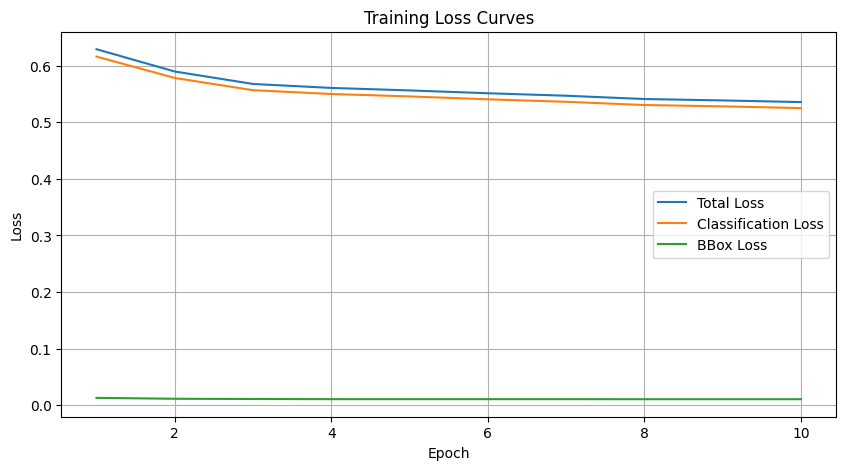

In [32]:
plt.figure(figsize=(10,5))

plt.plot(history["epoch"], history["total_loss"], label="Total Loss")
plt.plot(history["epoch"], history["cls_loss"], label="Classification Loss")
plt.plot(history["epoch"], history["bbox_loss"], label="BBox Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
from sklearn.metrics import roc_curve, auc

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, gt_boxes, has_object in train_loader:

        images = images.to(device)

        obj_logits, _ = model(images)

        probs = torch.sigmoid(obj_logits).cpu().numpy()

        all_probs.extend(probs.flatten())
        all_labels.extend(has_object.numpy())

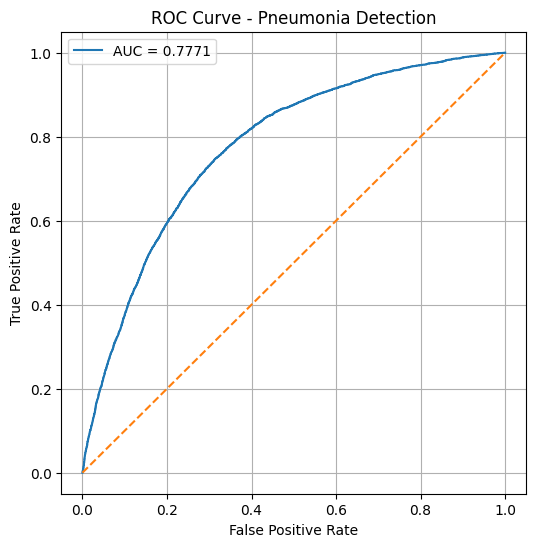

In [34]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Pneumonia Detection")

plt.legend()
plt.grid()

plt.show()

In [35]:
youden_index = tpr - fpr

best_index = np.argmax(youden_index)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("TPR at best threshold:", tpr[best_index])
print("FPR at best threshold:", fpr[best_index])

Best Threshold: 0.32709482
TPR at best threshold: 0.7465201465201465
FPR at best threshold: 0.31298374613003094


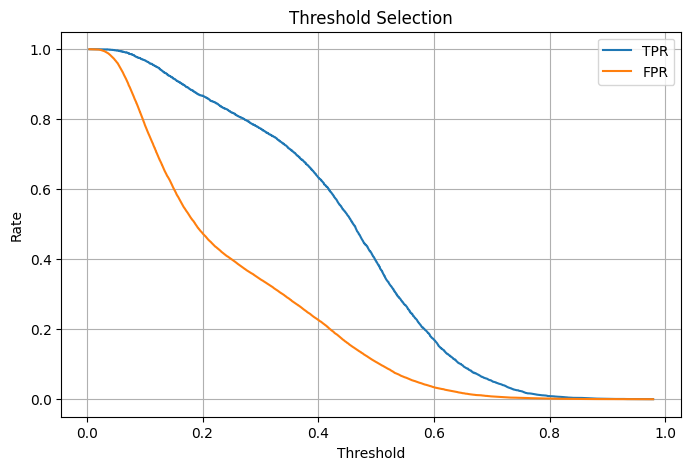

In [36]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, tpr, label="TPR")
plt.plot(thresholds, fpr, label="FPR")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Threshold Selection")

plt.legend()
plt.grid()

plt.show()

In [37]:
roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
})

roc_df.to_csv("roc_curve_data.csv", index=False)

In [38]:
from sklearn.metrics import roc_curve, auc

model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, gt_boxes, has_object in train_loader:

        images = images.to(device)

        obj_logits, _ = model(images)

        probs = torch.sigmoid(obj_logits).cpu().numpy()

        all_probs.extend(probs.flatten())
        all_labels.extend(has_object.numpy())

KeyboardInterrupt: 

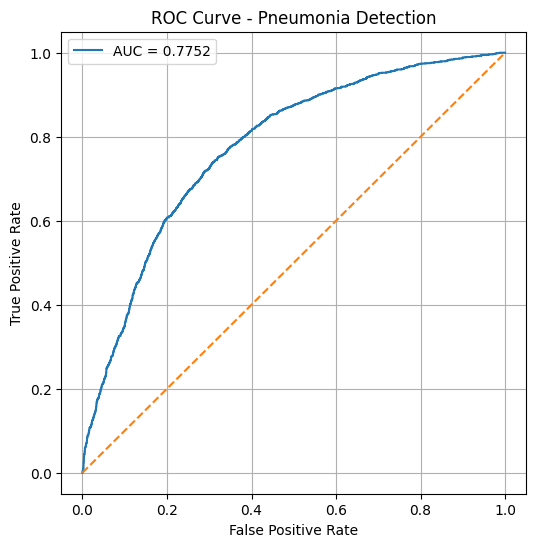

In [39]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Pneumonia Detection")

plt.legend()
plt.grid()

plt.show()

In [40]:
import numpy as np

youden_index = tpr - fpr
best_index = np.argmax(youden_index)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.34011123


In [41]:
y_pred = (np.array(all_probs) > best_threshold).astype(int)
y_true = np.array(all_labels)

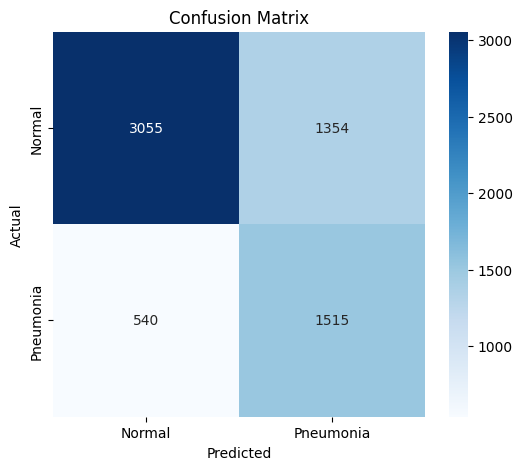

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.85      0.69      0.76      4409
         1.0       0.53      0.74      0.62      2055

    accuracy                           0.71      6464
   macro avg       0.69      0.72      0.69      6464
weighted avg       0.75      0.71      0.72      6464



In [44]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

Sensitivity (Recall): 0.7372262773722628
Specificity: 0.6929008845543208


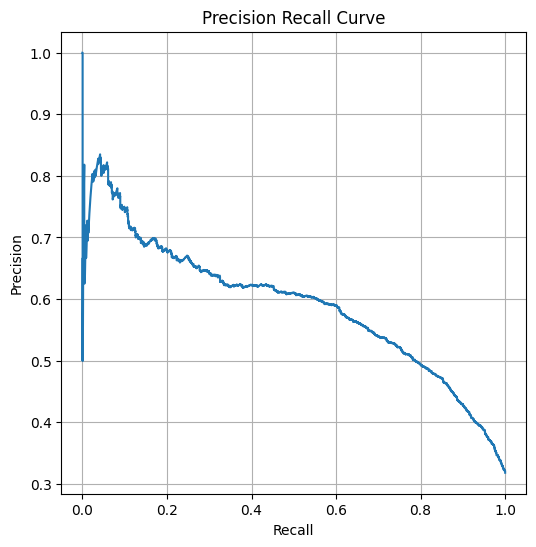

In [45]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, all_probs)

plt.figure(figsize=(6,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.grid()

plt.show()

In [46]:
results = {
    "AUC": roc_auc,
    "Best Threshold": best_threshold,
    "Sensitivity": sensitivity,
    "Specificity": specificity
}

results_df = pd.DataFrame([results])
results_df.to_csv("evaluation_metrics.csv", index=False)

print("Evaluation metrics saved")

Evaluation metrics saved
